# 04 — Free Exploration: B3 Financial Analysis

Open-ended exploration notebook using the Gold layer.
Use the data already processed through the Medallion pipeline for ad-hoc analysis.

Topics covered:
1. Correlation matrix between tickers
2. Bollinger Bands for a selected ticker
3. Simple Equal-Weight Portfolio back-test
4. Volume anomaly detection (z-score)
5. PySpark exploration with Spark SQL

In [2]:
# Imports usados na exploração livre da camada Gold.
import sys
sys.path.insert(0, "..")

import polars as pl
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns

pl.Config.set_tbl_rows(30)

polars.config.Config

In [3]:
# Carrega as tabelas Gold persistidas — ponto de partida da exploração.
from d_processing.gold.aggregate import read_gold

daily = read_gold("daily_metrics")
summary = read_gold("portfolio_summary")

print(f"daily_metrics : {len(daily):,} rows")
print(f"portfolio_summary: {len(summary):,} rows")

{"timestamp": "2026-06-26T11:38:09.596522+00:00", "level": "INFO", "logger": "d_processing.gold.aggregate", "message": "Gold read complete", "module": "aggregate", "func": "read_gold", "line": 163, "name": "d_processing.gold.aggregate", "msg": "Gold read complete", "args": [], "levelname": "INFO", "levelno": 20, "pathname": "\\\\wsl.localhost\\ubuntu-llm\\home\\efcardoso\\projects\\b3-data-plataform\\i_notebooks\\..\\d_processing\\gold\\aggregate.py", "filename": "aggregate.py", "exc_info": null, "exc_text": null, "stack_info": null, "lineno": 163, "funcName": "read_gold", "created": 1782473889.5964453, "msecs": 596.0, "relativeCreated": 211976.4928, "thread": 14932, "threadName": "MainThread", "processName": "MainProcess", "process": 360, "taskName": "Task-72", "table": "daily_metrics", "rows": 720}
{"timestamp": "2026-06-26T11:38:09.638727+00:00", "level": "INFO", "logger": "d_processing.gold.aggregate", "message": "Gold read complete", "module": "aggregate", "func": "read_gold", "li

## 1. Correlation Matrix

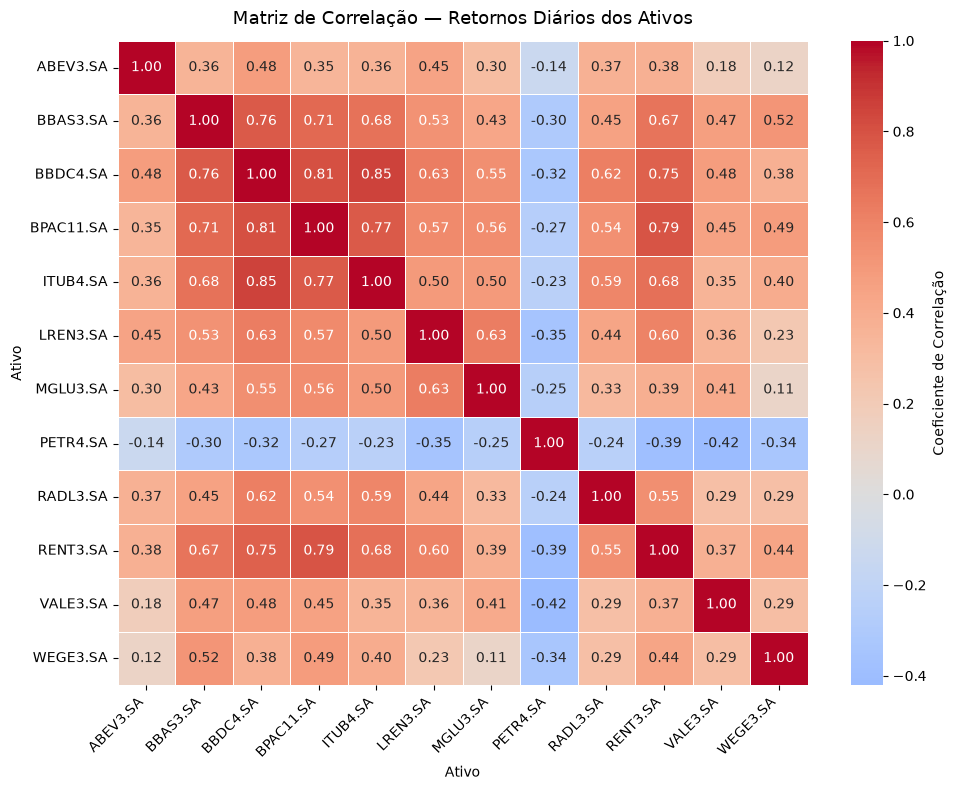

In [4]:
# 1) Matriz de correlação entre os retornos diários dos ativos.
# Valores próximos de 1: ativos andam juntos; próximos de -1: andam em oposição.
# Útil para análise de diversificação de portfólio.
if not daily.is_empty():
    # Pivot do long-format (ticker, trade_date, daily_return) para wide
    # onde cada coluna é um ativo e cada linha um dia.
    wide = (
        daily
        .select(["ticker", "trade_date", "daily_return"])
        .pivot(values="daily_return", index="trade_date", on="ticker")
        .sort("trade_date")
        .to_pandas()
        .set_index("trade_date")
        .astype(float)
    )

    # pandas.DataFrame.corr() usa Pearson por padrão.
    corr = wide.corr()

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",   # divergente azul (negativa) → vermelha (positiva)
        center=0,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Coeficiente de Correlação"},
        ax=ax,
    )
    ax.set_title("Matriz de Correlação — Retornos Diários dos Ativos", fontsize=13, pad=12)
    ax.set_xlabel("Ativo")
    ax.set_ylabel("Ativo")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 2. Bollinger Bands

In [5]:
# 2) Bandas de Bollinger para um ativo selecionado.
# Construção:
#   - Média móvel (SMA) de 20 dias do preço de fechamento.
#   - Bandas = SMA ± 2 desvios-padrão.
# Interpretação clássica: preço tocando a banda superior pode indicar
# sobrecompra; tocando a inferior, sobrevenda.
TICKER = "PETR4.SA"

if not daily.is_empty():
    bb = (
        daily
        .filter(pl.col("ticker") == TICKER)
        .sort("trade_date")
        .with_columns([
            pl.col("close_price").rolling_mean(window_size=20, min_samples=1).alias("sma_20"),
            pl.col("close_price").rolling_std(window_size=20, min_samples=2).alias("std_20"),
        ])
        .with_columns([
            (pl.col("sma_20") + 2 * pl.col("std_20")).alias("upper_band"),
            (pl.col("sma_20") - 2 * pl.col("std_20")).alias("lower_band"),
        ])
        .to_pandas()
    )

    # Ordem dos traces escolhida para que o preço fique POR CIMA das bandas.
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=bb["trade_date"], y=bb["upper_band"],
        name="Banda Superior (+2σ)", line=dict(color="rgba(220,60,60,0.9)", dash="dash"),
    ))
    fig.add_trace(go.Scatter(
        x=bb["trade_date"], y=bb["lower_band"],
        name="Banda Inferior (-2σ)", line=dict(color="rgba(60,170,60,0.9)", dash="dash"),
        fill="tonexty", fillcolor="rgba(120,180,255,0.12)",   # sombreado entre bandas
    ))
    fig.add_trace(go.Scatter(
        x=bb["trade_date"], y=bb["sma_20"],
        name="Média Móvel 20 dias", line=dict(color="orange", width=2),
    ))
    fig.add_trace(go.Scatter(
        x=bb["trade_date"], y=bb["close_price"],
        name="Preço de Fechamento", line=dict(color="royalblue", width=2.2),
    ))
    fig.update_layout(
        title=f"Bandas de Bollinger — {TICKER}",
        xaxis_title="Data da Negociação",
        yaxis_title="Preço (R$)",
        template="plotly_white",
        height=520,
        hovermode="x unified",
        legend=dict(orientation="h", y=-0.18, x=0.5, xanchor="center"),
        margin=dict(l=60, r=40, t=70, b=60),
    )
    fig.update_yaxes(tickprefix="R$ ", separatethousands=True)
    fig.update_xaxes(tickformat="%d/%m/%Y")
    fig.show()

## 3. Equal-Weight Portfolio Back-test

In [6]:
# 3) Back-test simples de um portfólio igualmente ponderado (equal-weight).
# Estratégia: a cada dia, peso = 1/N em cada ativo. O retorno do portfólio é a
# média simples dos retornos diários; o acumulado é o produto cumulativo.
if not daily.is_empty():
    portfolio = (
        daily
        .group_by("trade_date")
        .agg(pl.col("daily_return").mean().alias("portfolio_return"))
        .sort("trade_date")
        .with_columns(
            # cumprod((1 + r_t)) - 1  =  retorno composto acumulado
            ((1 + pl.col("portfolio_return").fill_null(0)).cum_prod() - 1).alias("portfolio_cum_return")
        )
        .to_pandas()
    )

    fig = px.line(
        portfolio,
        x="trade_date",
        y="portfolio_cum_return",
        title="Retorno Acumulado — Portfólio Igualmente Ponderado",
        labels={
            "trade_date": "Data da Negociação",
            "portfolio_cum_return": "Retorno Acumulado",
        },
    )
    fig.update_traces(line=dict(color="#1f77b4", width=2.4))
    fig.add_hline(y=0, line_dash="dash", line_color="grey")
    fig.update_layout(
        template="plotly_white",
        height=480,
        hovermode="x unified",
        margin=dict(l=60, r=40, t=70, b=50),
    )
    fig.update_yaxes(tickformat=".1%")
    fig.update_xaxes(tickformat="%d/%m/%Y")
    fig.show()

    final_return = portfolio["portfolio_cum_return"].iloc[-1]
    print(f"Retorno final do portfólio: {final_return:.2%}")

Retorno final do portfólio: -10.29%


## 4. Volume Anomaly Detection (Z-Score)

In [7]:
# 4) Detecção de anomalias de volume usando z-score.
# Para cada ativo: calcula média e desvio em janela móvel de 20 dias e
# marca como anomalia qualquer dia cujo volume esteja a mais de 3 desvios
# da média recente (|z| > 3). Útil para detectar dias atípicos
# (rumores, fato relevante, leilão, etc.).
if not daily.is_empty():
    anomalies = (
        daily
        .with_columns([
            pl.col("volume").rolling_mean(window_size=20, min_samples=5).over("ticker").alias("vol_mean"),
            pl.col("volume").rolling_std(window_size=20, min_samples=5).over("ticker").alias("vol_std"),
        ])
        .with_columns(
            ((pl.col("volume") - pl.col("vol_mean")) / pl.col("vol_std")).alias("vol_zscore")
        )
        .filter(pl.col("vol_zscore").abs() > 3)  # apenas pontos verdadeiramente extremos
        .select(["ticker", "trade_date", "volume", "vol_mean", "vol_zscore"])
        .sort("vol_zscore", descending=True)
    )

    print(f"Volume anomalies detected (|z| > 3): {len(anomalies)}")
    anomalies.head(20)

Volume anomalies detected (|z| > 3): 9


## 5. PySpark — Spark SQL on Gold Data

In [11]:
# 5a) Bootstrap de uma SparkSession local com Delta Lake habilitado.
# Em produção, este mesmo factory é usado pelos jobs Spark de larger-scale.
# Requer um JDK 8/11/17 instalado e JAVA_HOME apontando para ele.
import os
import sys
import shutil

# Garante que a raiz do projeto está no sys.path mesmo se esta célula
# for executada isoladamente (sem rodar a célula de imports antes).
if ".." not in sys.path:
    sys.path.insert(0, "..")

from a_configs.spark_config import create_spark_session

spark = None
java_available = bool(os.environ.get("JAVA_HOME")) or shutil.which("java") is not None

if not java_available:
    print(
        "Java não encontrado neste ambiente.\n"
        "Para rodar a seção PySpark instale um JDK (8/11/17) e defina JAVA_HOME.\n"
        "  Ubuntu/WSL : sudo apt-get install -y openjdk-17-jdk-headless\n"
        "  Windows    : winget install Microsoft.OpenJDK.17\n"
        "Pulando as células 5b e 5c."
    )
else:
    try:
        spark = create_spark_session("b3-exploration")
        spark.sparkContext.setLogLevel("ERROR")
        print(f"Spark version: {spark.version}")
    except Exception as exc:
        spark = None
        print(f"Falha ao iniciar a SparkSession: {exc}\nPulando as células 5b e 5c.")

Falha ao iniciar a SparkSession: [JAVA_GATEWAY_EXITED] Java gateway process exited before sending its port number.
Pulando as células 5b e 5c.


In [9]:
# 5b) Consulta SQL diretamente sobre o Parquet da Gold.
# Demonstra que a saída do pipeline (Parquet) é nativamente consultável
# por qualquer engine SQL distribuído.
from pathlib import Path
from a_configs.settings import DATA_PATH_GOLD

gold_parquet_path = str(DATA_PATH_GOLD / "daily_metrics")

if spark is None:
    print("SparkSession indisponível — célula 5a não inicializou. Pulando.")
elif not Path(gold_parquet_path).exists():
    print("Gold Parquet not found — run GoldPipeline first (notebook 03)")
else:
    # Lê o Parquet particionado e registra uma view temporária.
    sdf = spark.read.parquet(gold_parquet_path)
    sdf.createOrReplaceTempView("gold_daily")

    # Ranking simples por volatilidade média.
    result = spark.sql("""
        SELECT
            ticker,
            COUNT(*)                            AS trading_days,
            ROUND(AVG(close_price), 2)          AS avg_close,
            ROUND(AVG(volatility_20d) * 100, 2) AS avg_vol_pct,
            ROUND(MAX(cum_return) * 100, 2)     AS max_cum_return_pct
        FROM gold_daily
        GROUP BY ticker
        ORDER BY avg_vol_pct DESC
    """)
    result.show(20, truncate=False)

SparkSession indisponível — célula 5a não inicializou. Pulando.


In [10]:
# Encerra a SparkSession para liberar recursos do driver.
if spark is not None:
    spark.stop()
    print("SparkSession stopped")
else:
    print("Nenhuma SparkSession ativa para encerrar.")

Nenhuma SparkSession ativa para encerrar.
